# Tutorial 0: What MI Estimation Is Doing — and Why to Trust It

The other tutorials in this series show you *how* to get a correct mutual-information estimate:
how to format data, choose a split, sweep parameters, correct for bias, and validate the
result. This one steps back and builds the **mental model** underneath all of that. It answers
three questions:

1. **Why mutual information at all?** What does it capture that a correlation coefficient does not?
2. **How does a neural estimator turn "X and Y are related" into a number?**
3. **Which number does NeuralMI actually report**, and why is it computed that way?

Nothing here is required in order to *use* the library — but it makes every later choice (why a
permutation test is the right sanity check, why batch size matters, why tiny samples are
unreliable) feel inevitable rather than arbitrary.

In [1]:
import warnings
warnings.filterwarnings('ignore')   # keep this conceptual walkthrough's output clean

import numpy as np
import matplotlib.pyplot as plt
import neural_mi as nmi

## 1. Why mutual information, not correlation?

The Pearson correlation coefficient measures one specific thing: the strength of a **linear**
relationship. If Y tends to rise when X rises, correlation sees it. But if the relationship is
nonlinear — if Y depends on X in a way that isn't a straight line — correlation can report
**zero** even when X completely determines Y.

Mutual information has no such blind spot. It measures **any** statistical dependence: it is
zero if and only if X and Y are independent, and positive for *any* relationship, linear or not.

Below are three datasets. Watch what correlation says versus what MI says.

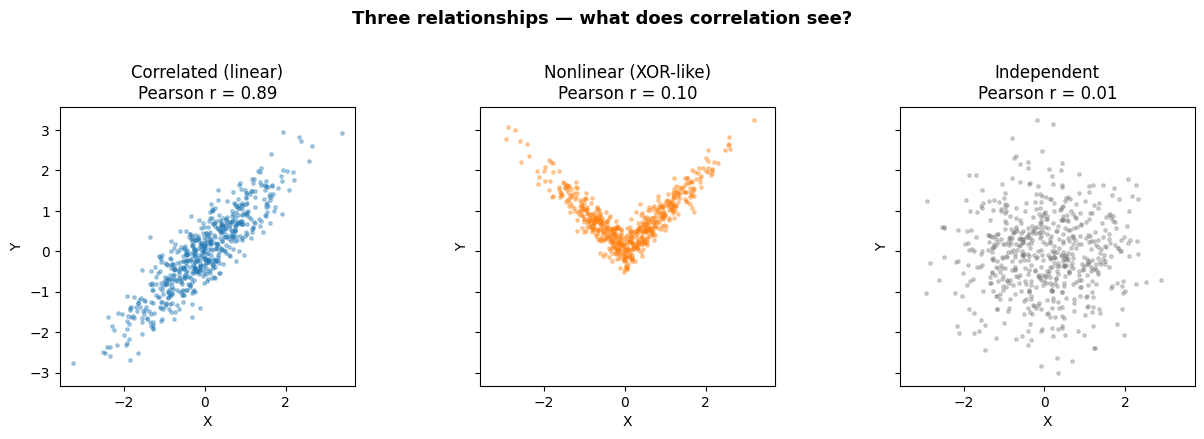

In [2]:
np.random.seed(42)
n = 600

# Case 1: correlated Gaussians  -> strong linear relationship
rho = 0.9
xy = np.random.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
x1, y1 = xy[:, 0], xy[:, 1]

# Case 2: nonlinear (XOR-like)  -> Y is set by |X|, but the Pearson r is ~ 0
x2 = np.random.randn(n)
y2 = np.where(x2 > 0, x2 + 0.25 * np.random.randn(n), -x2 + 0.25 * np.random.randn(n))

# Case 3: independent           -> no relationship at all
x3 = np.random.randn(n)
y3 = np.random.randn(n)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, (x, y, title, c) in zip(axes, [
    (x1, y1, 'Correlated (linear)',  'tab:blue'),
    (x2, y2, 'Nonlinear (XOR-like)', 'tab:orange'),
    (x3, y3, 'Independent',          'tab:gray'),
]):
    ax.scatter(x, y, s=6, alpha=0.35, color=c)
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.set_title(f'{title}\nPearson r = {np.corrcoef(x, y)[0, 1]:.2f}')
    ax.set_aspect('equal', 'box')
fig.suptitle('Three relationships — what does correlation see?',
             y=1.05, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Correlation flags Case 1 (large *r*) and correctly reports ~0 for Case 3. But it also reports
~0 for **Case 2** — even though Y there is entirely determined by X (through |X|). Correlation
is blind to that structure.

Now let's estimate the mutual information of each case with `nmi.run` and see the difference.

In [3]:
def estimate_mi(x, y):
    """A minimal MI estimate for scalar X and Y: reshape to (n_samples, 1) and run."""
    result = nmi.run(
        x.reshape(-1, 1).astype('float32'), y.reshape(-1, 1).astype('float32'),
        mode='estimate', split=nmi.Split(mode='random'),
        model=nmi.Model(hidden_dim=64, embedding_dim=16),
        training=nmi.Training(n_epochs=80, batch_size=128, patience=40),
        seed=0, show_progress=False,
    )
    return result.mi_estimate

for name, (x, y) in {
    'Correlated (linear)':  (x1, y1),
    'Nonlinear (XOR-like)': (x2, y2),
    'Independent':          (x3, y3),
}.items():
    print(f"{name:22s}  Pearson r = {np.corrcoef(x, y)[0, 1]:+.2f}   MI = {estimate_mi(x, y):.3f} bits")

Correlated (linear)     Pearson r = +0.89   MI = 1.055 bits


Nonlinear (XOR-like)    Pearson r = +0.10   MI = 1.175 bits


Independent             Pearson r = +0.01   MI = 0.011 bits


The estimator recovers what correlation misses: the **nonlinear** case has near-zero
correlation but clearly **positive MI** — the dependence is real, and MI finds it. The
independent case has both near-zero correlation and near-zero MI, and the linear case has both
high. Correlation is a special case; mutual information is the general tool.

(The nonlinear number won't be exactly its true value — estimating MI from finite samples is
itself the subject of Tutorials 1 and 5. The point here is only **positive vs. zero**.)

## 2. How a neural estimator turns dependence into a number

If MI measures dependence, how does the library actually compute it? The core idea is simple and
worth internalising, because it explains nearly every practical consideration in the rest of the
series.

**Real pairs vs. shuffled pairs.** Take your data and form two kinds of pairs:

- **Real pairs** $(x_i, y_i)$ — X and Y as they were actually observed together.
- **Shuffled pairs** $(x_i, y_j)$ — Y taken from a *different* sample, breaking any real link.

If X and Y are dependent, real pairs look systematically different from shuffled ones, and a
classifier (the library calls it a **critic**) can learn to tell them apart. If X and Y are
independent, real and shuffled pairs are statistically identical and no classifier can beat
chance.

**MI is how well that classifier can do.** Formally, the critic learns the log-ratio between the
joint density $p(x, y)$ and the product of marginals $p(x)\,p(y)$, and the mutual information is
the average of that log-ratio. The better the critic separates real from shuffled, the higher
the estimated MI.

This single picture explains the practical facts you meet later:

- **Why there is training at all.** The critic is a neural network, so the MI estimate is only
  as good as the classifier you manage to train. An *under-trained* critic separates the two
  classes poorly and therefore **under-estimates** MI.
- **Why the permutation test is the natural sanity check** (Tutorial 8). "Shuffle Y and
  re-estimate" is literally the always-shuffled case — it should give MI $\approx$ 0. If it does
  not, something is leaking (a wrong split, temporal correlation, or a bug).
- **Why batch size sets a ceiling** (Tutorial 8, Section 2). The default estimator, InfoNCE,
  contrasts each real pair against the other samples *in its batch*; with $N$ samples to contrast
  against, it can express at most $\log_2 N$ bits.

We can see the shuffled-vs-real contrast directly — the estimate on real data should sit well
above the estimate on shuffled data:

In [4]:
# Reuse the linear case: estimate MI on the real pairs, then on shuffled Y.
mi_real     = estimate_mi(x1, y1)
mi_shuffled = estimate_mi(x1, np.random.permutation(y1))
print(f"MI on real pairs:     {mi_real:.3f} bits")
print(f"MI on shuffled pairs: {mi_shuffled:.3f} bits   (this is the built-in null -- see Tutorial 8)")

MI on real pairs:     1.020 bits
MI on shuffled pairs: 0.000 bits   (this is the built-in null -- see Tutorial 8)


## 3. Which number does NeuralMI report?

Training a critic raises a subtle question: MI is read off the *trained* critic, but a neural
network keeps changing throughout training. Early on it underfits; late on it can **overfit**,
memorising the training pairs and reporting an MI that will not generalise. Which point in
training should we trust?

NeuralMI uses a **max-test heuristic**. It tracks MI on a held-out **test** set every epoch and
uses that curve for *model selection* — it picks the epoch where test MI is highest (the
best-generalising checkpoint). The **reported estimate is the train-set MI at that selected
epoch.** Test MI decides *when*; the reported number is the train MI *there*.

Let's make the two curves visible.

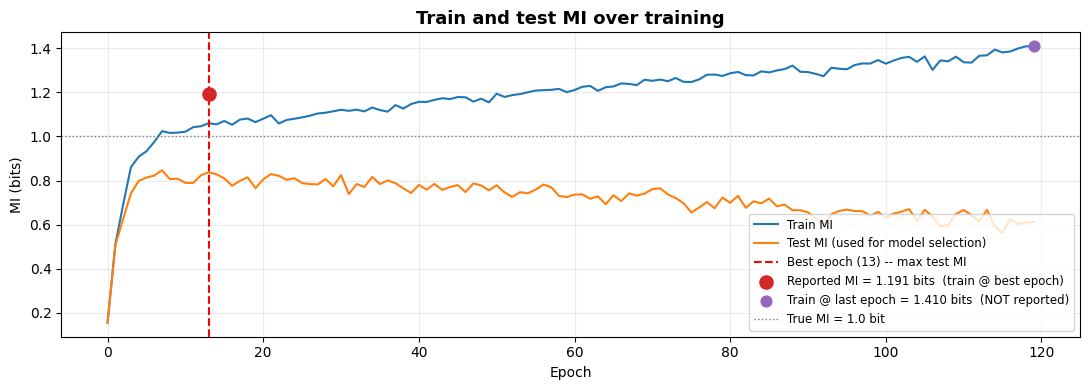

Reported MI (train @ best epoch): 1.191 bits
Train MI @ last epoch:            1.410 bits   (higher, but overfit)
True MI:                          1.000 bits


In [5]:
X_c, Y_c = nmi.generators.generate_nonlinear_from_latent(
    n_samples=1500, latent_dim=5, observed_dim=100, mi=1.0, use_torch=False)

# High patience disables early stopping so we can see the full training arc.
r_curves = nmi.run(
    X_c, Y_c, mode='estimate', split=nmi.Split(mode='random'),
    model=nmi.Model(hidden_dim=128, embedding_dim=64),
    training=nmi.Training(n_epochs=120, patience=120, learning_rate=1e-3, eval_train=True),
    seed=0, show_progress=False,
)

train_curve = r_curves.details['train_mi_history']
test_curve  = r_curves.details['test_mi_history']
best_ep     = r_curves.details['best_epoch']
last_ep     = len(train_curve) - 1

fig, ax = plt.subplots(figsize=(11, 4))
ep = range(len(train_curve))
ax.plot(ep, train_curve, color='tab:blue',   lw=1.5, label='Train MI')
ax.plot(ep, test_curve,  color='tab:orange', lw=1.5, label='Test MI (used for model selection)')
ax.axvline(best_ep, color='red', ls='--', lw=1.5, label=f'Best epoch ({best_ep}) -- max test MI')
# The reported estimate is the train MI at the selected epoch:
ax.scatter([best_ep], [r_curves.mi_estimate], color='tab:red', s=90, zorder=5,
           label=f'Reported MI = {r_curves.mi_estimate:.3f} bits  (train @ best epoch)')
ax.scatter([last_ep], [train_curve[last_ep]], color='tab:purple', s=60, zorder=5,
           label=f'Train @ last epoch = {train_curve[last_ep]:.3f} bits  (NOT reported)')
ax.axhline(1.0, color='gray', ls=':', lw=1, label='True MI = 1.0 bit')
ax.set_xlabel('Epoch'); ax.set_ylabel('MI (bits)')
ax.set_title('Train and test MI over training', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8.5); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

print(f"Reported MI (train @ best epoch): {r_curves.mi_estimate:.3f} bits")
print(f"Train MI @ last epoch:            {train_curve[last_ep]:.3f} bits   (higher, but overfit)")
print(f"True MI:                          1.000 bits")

Two things to take away:

- **Test MI is for model selection, not the headline number.** The library uses the held-out
  test curve to decide *when* the critic generalises best, then reports the train MI at that
  point. This is why turning on `eval_train=True` (Tutorial 8, Section 5c) and watching both
  curves is the most direct way to diagnose overfitting: a large train-test gap means the critic
  is memorising.
- **More training is not always better.** The train MI at the *last* epoch is higher, but it is
  inflated by overfitting and does not reflect the true dependence. Trusting it would over-report
  MI — exactly the failure the max-test heuristic guards against.

On small samples this guard is not enough on its own — the estimate is still biased and noisy,
which is why **Tutorial 5** adds explicit bias correction and a reliability check. But the
mechanism here is the foundation everything else builds on.

## Where to go next

You now have the mental model:

- MI captures **any** dependence, not just linear correlation (Section 1).
- It is computed by training a **critic** to separate real pairs from shuffled ones; MI is how
  well it can (Section 2).
- The reported number is the **train MI at the best-generalising checkpoint**, chosen by held-out
  test MI (Section 3).

With that in hand, the rest of the series is about getting the number *right* in practice:

- **Tutorial 1** — your first real estimate, end to end.
- **Tutorial 3** — choosing a data split so the test MI is trustworthy.
- **Tutorial 5** — correcting finite-sample bias and checking reliability.
- **Tutorial 8** — validating a result (permutation null, estimator ceilings, model choice).

For the mathematics behind the critic and the estimators, see `theory.md` and `concepts.md`.